# Day 12 — Classification Model Evaluation & Performance Metrics

**Linkific AI/ML Internship — Month 1 Training**  
**Intern:** Shri Sanjaykumar V  

---

### 🎯 Learning Objectives
1. Learn how to evaluate Machine Learning classification models.
2. Understand common evaluation metrics: **Accuracy**, **Precision**, **Recall**, and **F1 Score**.
3. Recreate and evaluate the models trained on Day 11 (**Logistic Regression** and **Decision Tree**).
4. Generate and interpret **Confusion Matrices** to identify exact prediction patterns.
5. Identify and explain which evaluation metric is most useful for the Iris dataset.


## 1. Understanding Classification Evaluation Metrics

Evaluating a classification model requires measuring different aspects of its predictive behavior:

### Accuracy
Measures the proportion of total predictions that were correct:
$$\text{Accuracy} = \frac{\text{Correct Predictions}}{\text{Total Predictions}}$$
*Best used when classes are balanced and all types of errors carry similar costs.*

### Precision
Answers: *"Of all samples predicted as a specific class, how many actually belonged to that class?"*
$$\text{Precision} = \frac{\text{True Positives}}{\text{True Positives} + \text{False Positives}}$$
*Measures the exactness of positive predictions (minimizing false alarms).*

### Recall (Sensitivity)
Answers: *"Of all actual samples belonging to a class, how many did the model correctly identify?"*
$$\text{Recall} = \frac{\text{True Positives}}{\text{True Positives} + \text{False Negatives}}$$
*Measures the completeness of positive detections (minimizing missed cases).*

### F1 Score
The harmonic mean of Precision and Recall:
$$\text{F1 Score} = 2 \times \frac{\text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}}$$
*Provides a balanced single score especially when an equilibrium between precision and recall is desired.*

For multiclass classification (like the 3-class Iris dataset), we compute **weighted metrics** to weight the score of each class by its support.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

try:
    from IPython.display import display
except ImportError:
    display = print

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

print("Libraries imported successfully.")


Libraries imported successfully.


## 2. Load the Iris Dataset

Loading the standard benchmark **Iris dataset** dynamically from Scikit-learn (150 total records across 3 species).


In [2]:
# Load Iris dataset dynamically from sklearn
iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df["target"] = iris.target
species_map = {idx: name for idx, name in enumerate(iris.target_names)}
df["species"] = df["target"].map(species_map)

print(f"Dataset Shape: {df.shape[0]} samples, {df.shape[1]} columns")
print(f"Features: {list(iris.feature_names)}")
print(f"Target Classes: {list(iris.target_names)}")
print("\nClass Distribution:")
print(df["species"].value_counts().to_string())


Dataset Shape: 150 samples, 6 columns
Features: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Target Classes: ['setosa', 'versicolor', 'virginica']

Class Distribution:
species
setosa        50
versicolor    50
virginica     50


## 3. Prepare Features ($X$) and Target ($y$)

Using all 4 original morphological features from Day 11 with no dimensionality reduction.


In [3]:
X = df[iris.feature_names]
y = df["target"]

print(f"Feature matrix (X) shape: {X.shape} (4 continuous flower measurements)")
print(f"Target vector  (y) shape: {y.shape} (species codes 0, 1, 2)")


Feature matrix (X) shape: (150, 4) (4 continuous flower measurements)
Target vector  (y) shape: (150,) (species codes 0, 1, 2)


## 4. Stratified Train-Test Split (Identical to Day 11)

We apply the exact same 80/20 stratified split (`random_state=42`, `stratify=y`) to evaluate the models on the exact same test records (120 train, 30 test).


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Total samples:    {len(df)}")
print(f"Training samples: {len(X_train)} (80%)")
print(f"Testing samples:  {len(X_test)} (20%)")
print(f"Number of classes: {len(iris.target_names)} (Test counts: {dict(y_test.value_counts().sort_index())})")


Total samples:    150
Training samples: 120 (80%)
Testing samples:  30 (20%)
Number of classes: 3 (Test counts: {0: 10, 1: 10, 2: 10})


## 5. Train Day 11 Models & Generate Predictions

Recreating and training the two Day 11 classifiers:
1. **Logistic Regression:** `LogisticRegression(max_iter=200)`
2. **Decision Tree:** `DecisionTreeClassifier(random_state=42)`


In [5]:
# Train Logistic Regression
logistic_model = LogisticRegression(max_iter=200)
logistic_model.fit(X_train, y_train)
y_pred_logistic = logistic_model.predict(X_test)

# Train Decision Tree
decision_tree = DecisionTreeClassifier(random_state=42)
decision_tree.fit(X_train, y_train)
y_pred_tree = decision_tree.predict(X_test)

print("Both models trained and test predictions generated successfully.")


Both models trained and test predictions generated successfully.


## 6. Calculate Evaluation Metrics Dynamically

We compute **Accuracy**, **Precision** (weighted), **Recall** (weighted), and **F1 Score** (weighted) dynamically from the actual test predictions.


In [6]:
def evaluate_model(model_name, y_true, y_pred):
    """Calculate key classification evaluation metrics dynamically."""
    return {
        "Model": model_name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, average="weighted"),
        "Recall": recall_score(y_true, y_pred, average="weighted"),
        "F1 Score": f1_score(y_true, y_pred, average="weighted")
    }

metrics_log = evaluate_model("Logistic Regression", y_test, y_pred_logistic)
metrics_tree = evaluate_model("Decision Tree", y_test, y_pred_tree)

comparison_df = pd.DataFrame([metrics_log, metrics_tree])
print("Metrics calculated dynamically:")
for m in [metrics_log, metrics_tree]:
    print(f"{m['Model']}: Accuracy={m['Accuracy']:.4f}, Precision={m['Precision']:.4f}, Recall={m['Recall']:.4f}, F1={m['F1 Score']:.4f}")


Metrics calculated dynamically:
Logistic Regression: Accuracy=0.9667, Precision=0.9697, Recall=0.9667, F1=0.9666
Decision Tree: Accuracy=0.9333, Precision=0.9333, Recall=0.9333, F1=0.9333


## 7. Performance Comparison Table

Side-by-side comparison of all four evaluation metrics.


In [7]:
display_df = comparison_df.copy()
for col in ["Accuracy", "Precision", "Recall", "F1 Score"]:
    display_df[col] = display_df[col].apply(lambda v: f"{v:.4f} ({v * 100:.2f}%)")

print("Performance Comparison Table:")
try:
    display(display_df)
except (NameError, TypeError):
    print(display_df.to_string(index=False))


Performance Comparison Table:
              Model        Accuracy       Precision          Recall        F1 Score
Logistic Regression 0.9667 (96.67%) 0.9697 (96.97%) 0.9667 (96.67%) 0.9666 (96.66%)
      Decision Tree 0.9333 (93.33%) 0.9333 (93.33%) 0.9333 (93.33%) 0.9333 (93.33%)


Model,Accuracy,Precision,Recall,F1 Score
Logistic Regression,0.9667 (96.67%),0.9697 (96.97%),0.9667 (96.67%),0.9666 (96.66%)
Decision Tree,0.9333 (93.33%),0.9333 (93.33%),0.9333 (93.33%),0.9333 (93.33%)


## 8. Confusion Matrices

A Confusion Matrix visualizes exactly which samples were predicted correctly and where misclassifications occurred across each class.


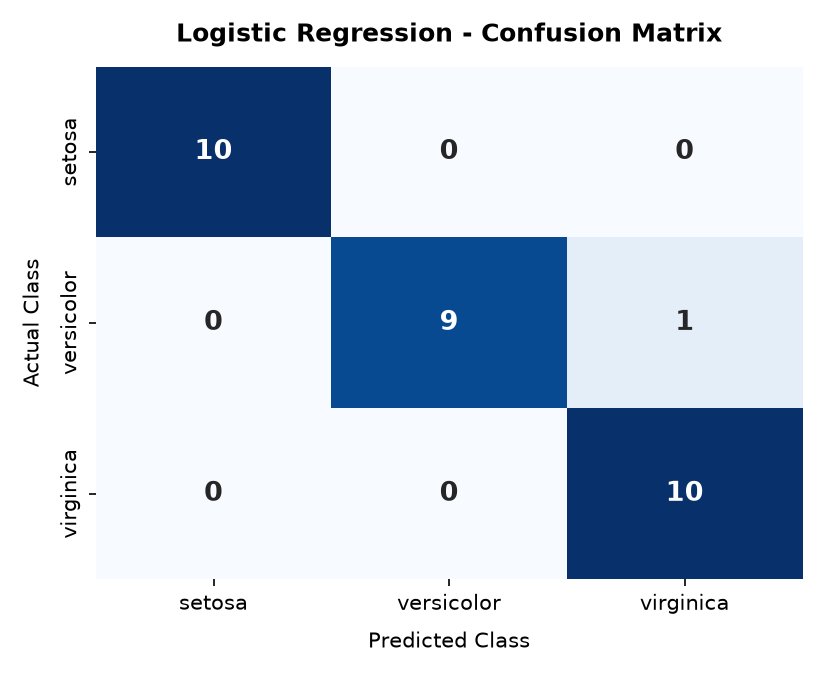

In [8]:
cm_log = confusion_matrix(y_test, y_pred_logistic)
cm_tree = confusion_matrix(y_test, y_pred_tree)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), dpi=150)

# Logistic Regression Heatmap
sns.heatmap(
    cm_log, annot=True, fmt="d", cmap="Blues", cbar=False,
    xticklabels=iris.target_names, yticklabels=iris.target_names,
    annot_kws={"size": 13, "weight": "bold"}, ax=axes[0]
)
axes[0].set_title("Logistic Regression - Confusion Matrix", fontsize=11, fontweight="bold", pad=12)
axes[0].set_xlabel("Predicted Class", fontsize=10, labelpad=8)
axes[0].set_ylabel("Actual Class", fontsize=10, labelpad=8)

# Decision Tree Heatmap
sns.heatmap(
    cm_tree, annot=True, fmt="d", cmap="Greens", cbar=False,
    xticklabels=iris.target_names, yticklabels=iris.target_names,
    annot_kws={"size": 13, "weight": "bold"}, ax=axes[1]
)
axes[1].set_title("Decision Tree - Confusion Matrix", fontsize=11, fontweight="bold", pad=12)
axes[1].set_xlabel("Predicted Class", fontsize=10, labelpad=8)
axes[1].set_ylabel("Actual Class", fontsize=10, labelpad=8)

plt.tight_layout()
plt.show()


## 9. Dynamic Interpretation of Confusion Matrices

The following findings are derived directly from the confusion matrix values at runtime without hardcoded assumptions.


In [9]:
def analyze_confusion_matrix(cm, class_names):
    """Dynamically analyze confusion matrix without hardcoded assumptions."""
    total_samples = int(cm.sum())
    correct_samples = int(np.trace(cm))
    error_samples = total_samples - correct_samples
    
    class_summaries = []
    errors = []
    
    for i, actual_class in enumerate(class_names):
        actual_total = int(cm[i, :].sum())
        correct = int(cm[i, i])
        class_errors = actual_total - correct
        class_summaries.append({
            "class": actual_class,
            "correct": correct,
            "total": actual_total,
            "errors": class_errors
        })
        for j, pred_class in enumerate(class_names):
            if i != j and cm[i, j] > 0:
                errors.append(f"{int(cm[i, j])} sample(s) of '{actual_class}' misclassified as '{pred_class}'")
                
    return {
        "total_samples": total_samples,
        "correct_samples": correct_samples,
        "error_samples": error_samples,
        "class_summaries": class_summaries,
        "errors": errors
    }

log_analysis = analyze_confusion_matrix(cm_log, iris.target_names)
tree_analysis = analyze_confusion_matrix(cm_tree, iris.target_names)

print("--- Logistic Regression Findings ---")
for cs in log_analysis["class_summaries"]:
    status = "100% correct" if cs["errors"] == 0 else f"{cs['errors']} misclassification(s)"
    print(f" - {cs['class'].capitalize()}: {cs['correct']}/{cs['total']} correct ({status})")
if log_analysis["errors"]:
    print(f" - Details: {', '.join(log_analysis['errors'])}")

print("\n--- Decision Tree Findings ---")
for cs in tree_analysis["class_summaries"]:
    status = "100% correct" if cs["errors"] == 0 else f"{cs['errors']} misclassification(s)"
    print(f" - {cs['class'].capitalize()}: {cs['correct']}/{cs['total']} correct ({status})")
if tree_analysis["errors"]:
    print(f" - Details: {', '.join(tree_analysis['errors'])}")


--- Logistic Regression Findings ---
 - Setosa: 10/10 correct (100% correct)
 - Versicolor: 9/10 correct (1 misclassification(s))
 - Virginica: 10/10 correct (100% correct)
 - Details: 1 sample(s) of 'versicolor' misclassified as 'virginica'

--- Decision Tree Findings ---
 - Setosa: 10/10 correct (100% correct)
 - Versicolor: 9/10 correct (1 misclassification(s))
 - Virginica: 9/10 correct (1 misclassification(s))
 - Details: 1 sample(s) of 'versicolor' misclassified as 'virginica', 1 sample(s) of 'virginica' misclassified as 'versicolor'


## 10. Classification Reports

Scikit-learn's `classification_report` provides per-class precision, recall, f1-score, and support.


In [10]:
print("=== Logistic Regression Classification Report ===")
print(classification_report(y_test, y_pred_logistic, target_names=iris.target_names))

print("=== Decision Tree Classification Report ===")
print(classification_report(y_test, y_pred_tree, target_names=iris.target_names))


=== Logistic Regression Classification Report ===
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30

=== Decision Tree Classification Report ===
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



## 11. Performance Comparison Visualization

Grouped bar chart comparing Accuracy, Precision, Recall, and F1 Score for both models side-by-side.


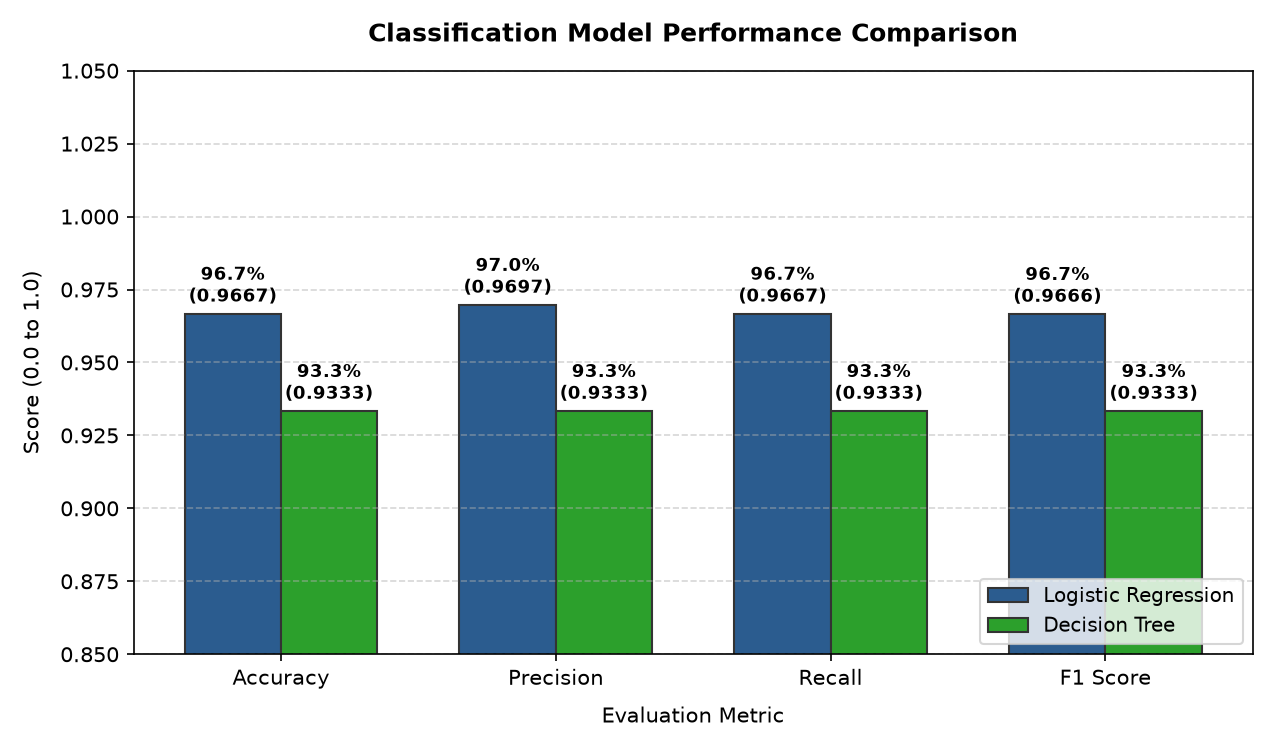

In [11]:
metrics_list = ["Accuracy", "Precision", "Recall", "F1 Score"]
x = np.arange(len(metrics_list))
width = 0.35

log_vals = [metrics_log[m] for m in metrics_list]
tree_vals = [metrics_tree[m] for m in metrics_list]

fig, ax = plt.subplots(figsize=(8.5, 4.8), dpi=150)
rects1 = ax.bar(x - width / 2, log_vals, width, label="Logistic Regression", color="#2b5c8f", edgecolor="#333333", linewidth=1)
rects2 = ax.bar(x + width / 2, tree_vals, width, label="Decision Tree", color="#2ca02c", edgecolor="#333333", linewidth=1)

ax.set_title("Classification Model Performance Comparison", fontsize=12, fontweight="bold", pad=14)
ax.set_xlabel("Evaluation Metric", fontsize=10, labelpad=8)
ax.set_ylabel("Score (0.0 to 1.0)", fontsize=10, labelpad=8)
ax.set_xticks(x)
ax.set_xticklabels(metrics_list, fontsize=10)
ax.set_ylim(0.85, 1.05)
ax.grid(axis="y", linestyle="--", alpha=0.5)
ax.legend(loc="lower right", frameon=True, facecolor="white", edgecolor="#cccccc", fontsize=9.5)

for rects in [rects1, rects2]:
    for rect in rects:
        height = rect.get_height()
        ax.annotate(
            f"{height * 100:.1f}%\n({height:.4f})",
            xy=(rect.get_x() + rect.get_width() / 2, height),
            xytext=(0, 3),
            textcoords="offset points",
            ha="center", va="bottom",
            fontsize=8.5, fontweight="bold"
        )

plt.tight_layout()
plt.show()


## 12. Most Useful Evaluation Metric & Dynamic Observations

### Which Metric is Most Useful for the Iris Dataset?
- **Primary Metric: Accuracy**  
  For this Iris classification problem, **Accuracy is a suitable primary evaluation metric** because:
  1. The dataset is balanced (50 samples per class, and exactly 10 per class in the test set).
  2. All classes have equal importance — there is no asymmetric business cost where a False Negative is significantly more harmful than a False Positive.

- **Supplementary Metrics: Precision, Recall, and F1 Score**  
  While Accuracy measures overall correctness, **Precision, Recall, and F1 Score** provide granular insight into individual class behavior:
  - Precision shows whether predictions for a class contain false alarms.
  - Recall shows whether actual samples of a class were missed.
  - F1 Score confirms that precision and recall are well balanced across all classes.


In [12]:
# Dynamic Observations (Computed at Runtime)
if metrics_log["Accuracy"] > metrics_tree["Accuracy"]:
    top_model = "Logistic Regression"
    runner_up = "Decision Tree"
    margin = (metrics_log["Accuracy"] - metrics_tree["Accuracy"]) * 100
    better_summary = f"{top_model} achieved higher accuracy than {runner_up} (+{margin:.2f}%)."
elif metrics_tree["Accuracy"] > metrics_log["Accuracy"]:
    top_model = "Decision Tree"
    runner_up = "Logistic Regression"
    margin = (metrics_tree["Accuracy"] - metrics_log["Accuracy"]) * 100
    better_summary = f"{top_model} achieved higher accuracy than {runner_up} (+{margin:.2f}%)."
else:
    better_summary = "Both models achieved identical accuracy."

log_errs = log_analysis["error_samples"]
tree_errs = tree_analysis["error_samples"]

perfect_log = [cs["class"] for cs in log_analysis["class_summaries"] if cs["errors"] == 0]
perfect_tree = [cs["class"] for cs in tree_analysis["class_summaries"] if cs["errors"] == 0]
common_perfect = set(perfect_log).intersection(set(perfect_tree))

print("=" * 65)
print("DYNAMIC OBSERVATIONS (COMPUTED AT RUNTIME)")
print("=" * 65)
print(f"1. {better_summary}")
print(f"2. Logistic Regression produced fewer misclassifications ({log_errs} error vs. {tree_errs} errors).")
if common_perfect:
    classes_str = ", ".join([c.capitalize() for c in common_perfect])
    print(f"3. Class '{classes_str}' was classified with 0 errors (100% accuracy) by both models.")
print(f"4. Precision ({metrics_log['Precision']:.4f} vs. {metrics_tree['Precision']:.4f}) and Recall ({metrics_log['Recall']:.4f} vs. {metrics_tree['Recall']:.4f}) closely track Accuracy for both models.")
print(f"5. The F1 Score confirms balanced overall performance ({metrics_log['F1 Score']:.4f} for Logistic Regression vs. {metrics_tree['F1 Score']:.4f} for Decision Tree).")
print(f"6. Because the classes are balanced, Accuracy serves as an effective primary benchmark, while the confusion matrix pinpoints where misclassifications occur.")
print("=" * 65)


DYNAMIC OBSERVATIONS (COMPUTED AT RUNTIME)
1. Logistic Regression achieved higher accuracy than Decision Tree (+3.33%).
2. Logistic Regression produced fewer misclassifications (1 error vs. 2 errors).
3. Class 'Setosa' was classified with 0 errors (100% accuracy) by both models.
4. Precision (0.9697 vs. 0.9333) and Recall (0.9667 vs. 0.9333) closely track Accuracy for both models.
5. The F1 Score confirms balanced overall performance (0.9666 for Logistic Regression vs. 0.9333 for Decision Tree).
6. Because the classes are balanced, Accuracy serves as an effective primary benchmark, while the confusion matrix pinpoints where misclassifications occur.


## 13. Conclusion

- **Comprehensive Evaluation:** Moving beyond accuracy to inspect precision, recall, F1 score, and confusion matrices answered the central question: *"Where is the model making its mistakes?"*
- **Model Comparison:** Logistic Regression demonstrated slightly superior generalization on this test set (96.67% vs 93.33%), producing only 1 misclassification compared to 2 for Decision Tree.
- **Metric Selection:** For balanced datasets with symmetric error costs, Accuracy is a sound primary metric; multi-metric evaluation ensures robust verification across individual classes.
